In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
conn = sqlite3.connect('sales.db') 

In [21]:
conn

In [23]:
#Q6 sorğusu üçün
q6_df = pd.read_sql("""WITH SiralanmisAltKateqoriyalar AS (
    SELECT 
        "Sub-Category" AS alt_kateqoriya,
        ROUND(SUM("Profit"), 2) AS umumi_menfeet,
        RANK() OVER (ORDER BY SUM("Profit") DESC) AS sira_yuxari,
        RANK() OVER (ORDER BY SUM("Profit") ASC) AS sira_asagi
    FROM orders
    GROUP BY "Sub-Category"
)
SELECT 
    alt_kateqoriya, 
    umumi_menfeet, 
    'En Yuksek 5' AS qrup_novu
FROM SiralanmisAltKateqoriyalar
WHERE sira_yuxari <= 5
UNION ALL
SELECT 
    alt_kateqoriya, 
    umumi_menfeet, 
    'En Asagi 5' AS qrup_novu
FROM SiralanmisAltKateqoriyalar
WHERE sira_asagi <= 5
ORDER BY umumi_menfeet DESC;""",conn)
display(q6_df)



,alt_kateqoriya,umumi_menfeet,qrup_novu
0,Copiers,55617.82,En Yuksek 5
1,Phones,44515.73,En Yuksek 5
2,Accessories,41936.64,En Yuksek 5
3,Paper,34053.57,En Yuksek 5
4,Binders,30221.76,En Yuksek 5
5,Machines,3384.76,En Asagi 5
6,Fasteners,949.52,En Asagi 5
7,Supplies,-1189.10,En Asagi 5
8,Bookcases,-3472.56,En Asagi 5
9,Tables,-17725.48,En Asagi 5


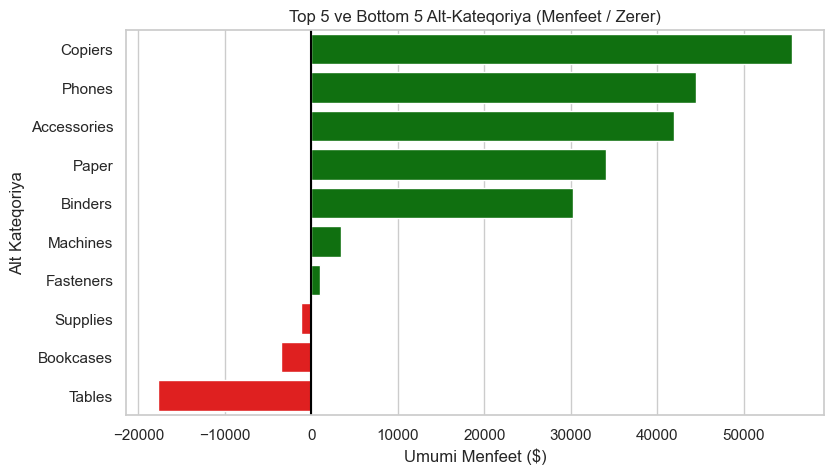

In [31]:
rengler = ['green' if x > 0 else 'red' for x in q6_df['umumi_menfeet']]

plt.figure(figsize=(9, 5))
sns.barplot(data=q6_df, x='umumi_menfeet', y='alt_kateqoriya', palette=rengler)

plt.axvline(0, color='black')

plt.title("Top 5 ve Bottom 5 Alt-Kateqoriya (Menfeet / Zerer)")
plt.xlabel("Umumi Menfeet ($)")
plt.ylabel("Alt Kateqoriya")

plt.show()

In [32]:
#Q7 sorğusu üçün
q7_df = pd.read_sql("""SELECT CASE 
       WHEN "Discount" = 0 THEN '0% Endirim Yoxdur'
       WHEN "Discount" > 0 AND "Discount" <= 0.20 THEN '1-20% Az Endirim'
       WHEN "Discount" > 0.20 AND "Discount" <= 0.40 THEN '21-40% Orta Endirim'
       ELSE '41%+ Yuksek Endirim'
    END AS endirim_qrupu,
    COUNT(*) AS umumi_sifaris_sayi,
    ROUND(SUM("Sales"), 2) AS umumi_satis,
    ROUND(SUM("Profit"), 2) AS umumi_menfeet,
    ROUND(AVG("Profit"), 2) AS ortalama_menfeet
FROM orders
GROUP BY endirim_qrupu
ORDER BY ortalama_menfeet DESC;""",conn)
display(q7_df)

,endirim_qrupu,umumi_sifaris_sayi,umumi_satis,umumi_menfeet,ortalama_menfeet
0,0% Endirim Yoxdur,4798,1087908.47,320987.60,66.90
1,1-20% Az Endirim,3803,846522.24,100785.47,26.50
2,21-40% Orta Endirim,460,234137.90,-35817.47,-77.86
3,41%+ Yuksek Endirim,933,128632.25,-99558.59,-106.71


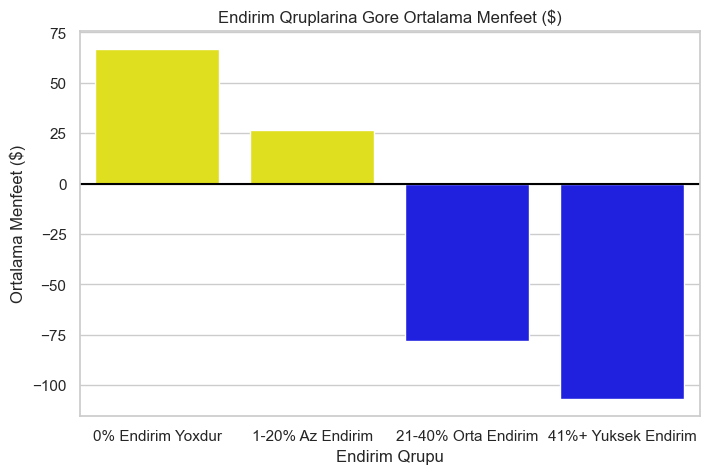

In [34]:
rengler = ['yellow' if x > 0 else 'blue' for x in q7_df['ortalama_menfeet']]

plt.figure(figsize=(8, 5))
sns.barplot(data=q7_df, x='endirim_qrupu', y='ortalama_menfeet', palette=rengler)
plt.axhline(0, color='black')

plt.title("Endirim Qruplarina Gore Ortalama Menfeet ($)")
plt.xlabel("Endirim Qrupu")
plt.ylabel("Ortalama Menfeet ($)")

plt.show()

In [47]:
#Q8 sorğusu üçün

q8_df = pd.read_sql("""
WITH IllikSatislar AS (
    SELECT 
        -- Tarih metninin en sonundaki 4 haneli yılı ayıklıyoruz (M/D/YYYY -> YYYY)
        SUBSTR("Order Date", -4) AS satis_ili,
        ROUND(SUM("Sales"), 2) AS umumi_satis
    FROM orders
    GROUP BY satis_ili
)
SELECT 
    satis_ili,
    umumi_satis,
    LAG(umumi_satis, 1) OVER (ORDER BY satis_ili) AS evvelki_il_satis,
    ROUND(((umumi_satis - LAG(umumi_satis, 1) OVER (ORDER BY satis_ili)) / LAG(umumi_satis, 1) OVER (ORDER BY satis_ili)) * 100, 2) AS illik_artim_faizi
FROM IllikSatislar
WHERE satis_ili IS NOT NULL AND satis_ili != '';
""", conn)

display(q8_df)

,satis_ili,umumi_satis,evvelki_il_satis,illik_artim_faizi
0,2014,484247.50,NaN,NaN
1,2015,470532.51,484247.50,-2.83
2,2016,609205.60,470532.51,29.47
3,2017,733215.26,609205.60,20.36


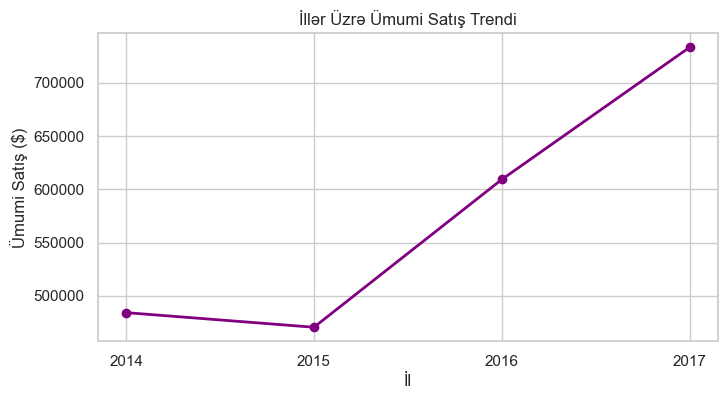

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(q8_df['satis_ili'].astype(str), q8_df['umumi_satis'], marker='o', color='purple', linewidth=2)

plt.title("İllər Üzrə Ümumi Satış Trendi")
plt.xlabel("İl")
plt.ylabel("Ümumi Satış ($)")
plt.grid(True)

plt.show()